<a href="https://colab.research.google.com/github/priyyyansh/House_price_prediction_model/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

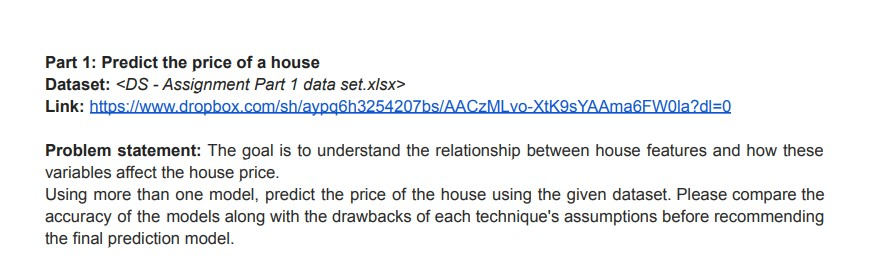

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline

In [ ]:
Data = pd.read_excel('/content/DS - Assignment Part 1 data set.xlsx')
Data.head(10)

,Transaction date,House Age,Distance from nearest Metro station (km),Number of convenience stores,latitude,longitude,Number of bedrooms,House size (sqft),House price of unit area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,1,575,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,2,1240,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,3,1060,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,2,875,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,1,491,43.1
5,2012.666667,7.1,2175.03000,3,24.96305,121.51254,3,828,32.1
6,2012.666667,34.5,623.47310,7,24.97933,121.53642,3,1115,40.3
7,2013.416667,20.3,287.60250,6,24.98042,121.54228,3,1316,46.7
8,2013.500000,31.7,5512.03800,1,24.95095,121.48458,1,588,18.8
9,2013.416667,17.9,1783.18000,3,24.96731,121.51486,2,1075,22.1


#Exploratory Data Analysis

In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Transaction date                          414 non-null    float64
 1   House Age                                 414 non-null    float64
 2   Distance from nearest Metro station (km)  414 non-null    float64
 3   Number of convenience stores              414 non-null    int64  
 4   latitude                                  414 non-null    float64
 5   longitude                                 414 non-null    float64
 6   Number of bedrooms                        414 non-null    int64  
 7   House size (sqft)                         414 non-null    int64  
 8   House price of unit area                  414 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 29.2 KB


#HeatMap using seaborn library.

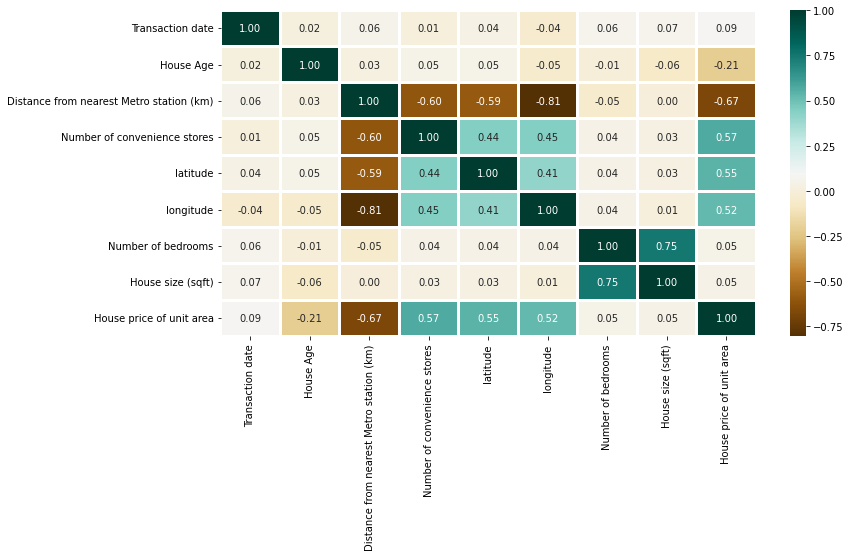

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(Data.corr(),
			cmap = 'BrBG',
			fmt = '.2f',
			linewidths = 2,
			annot = True)


/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


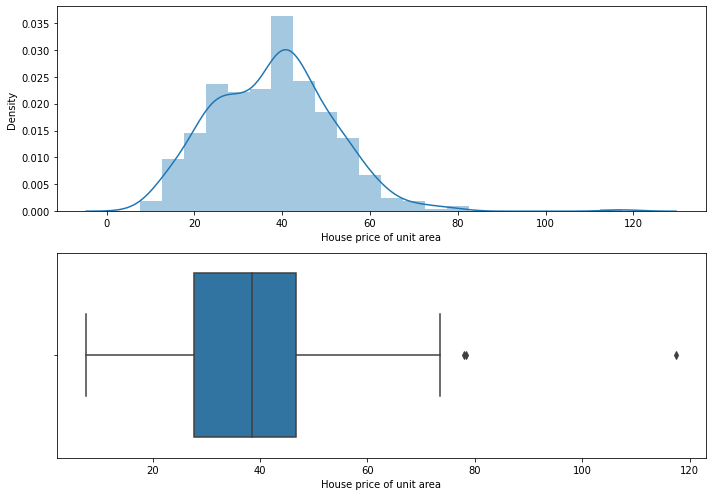

In [ ]:
fig = plt.figure(figsize=(10,7))
fig.add_subplot(2,1,1)
sns.distplot(Data['House price of unit area'])
fig.add_subplot(2,1,2)
sns.boxplot(Data['House price of unit area'])
plt.tight_layout()

#Data Cleaning


# Removing Outlier's

In [ ]:
Data.isnull().sum()

Transaction date                            0
House Age                                   0
Distance from nearest Metro station (km)    0
Number of convenience stores                0
latitude                                    0
longitude                                   0
Number of bedrooms                          0
House size (sqft)                           0
House price of unit area                    0
dtype: int64

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


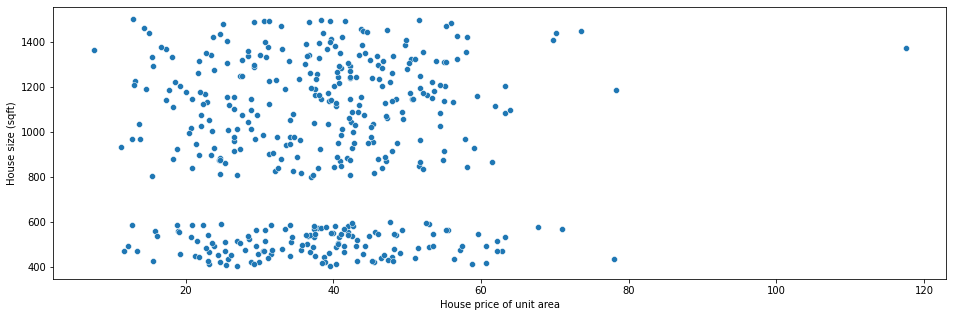

In [ ]:
fig = plt.figure(figsize=(16,5))
sns.scatterplot(Data['House price of unit area'],Data['House size (sqft)'])

In [ ]:
Data[['House price of unit area']].sort_values(by = 'House price of unit area',ascending=False).head(20)

,House price of unit area
270,117.5
220,78.3
312,78.0
166,73.6
105,71.0
16,70.1
379,69.7
389,67.7
413,63.9
361,63.3


In [ ]:
for i in range(len(Data)):
  x = Data.loc[i , 'House price of unit area']
  if x == 117.5:
    print(i)
    break

270


Removing more outlier's

In [ ]:
Data = Data[(Data['House price of unit area']<65) & (Data['House price of unit area']>10)]

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


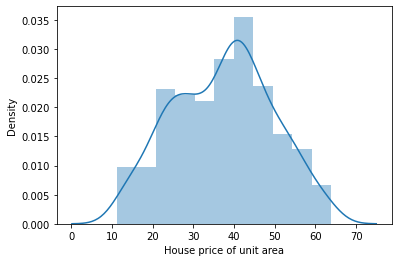

In [ ]:
sns.distplot(Data['House price of unit area'])

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


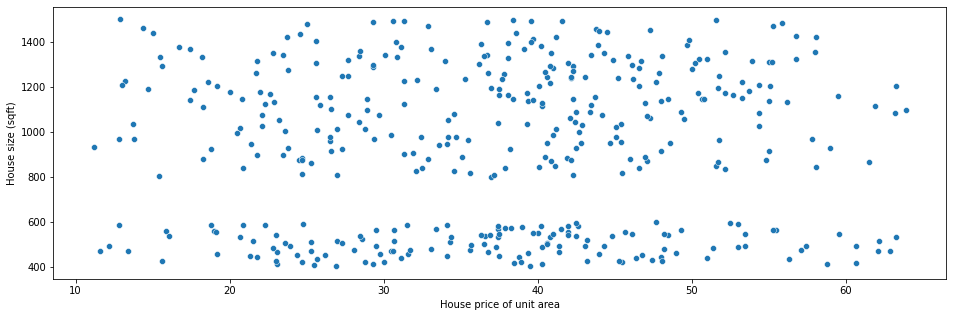

In [ ]:
fig = plt.figure(figsize=(16,5))
sns.scatterplot(Data['House price of unit area'],Data['House size (sqft)'])

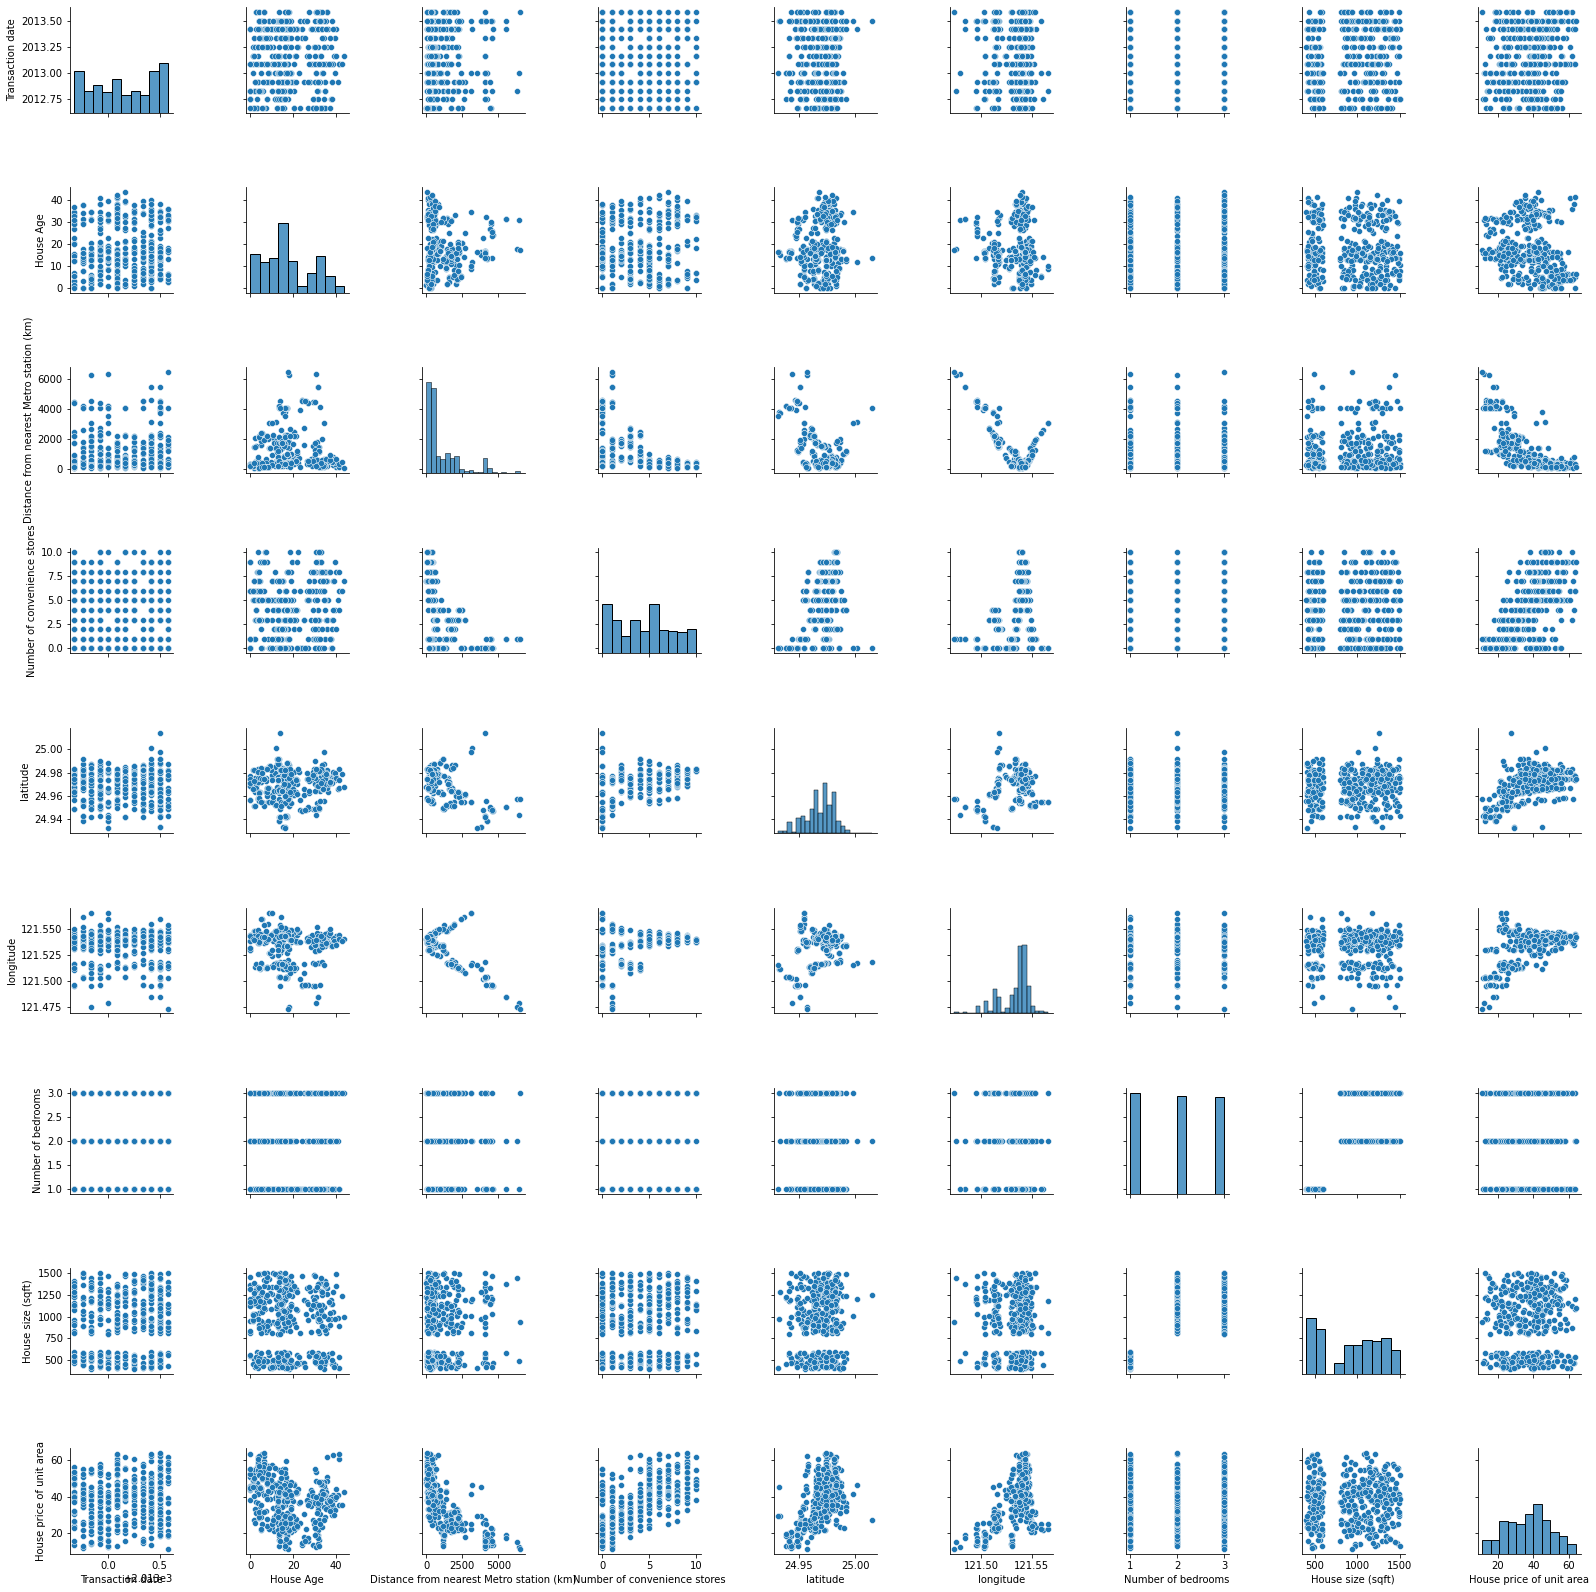

In [ ]:
sns.pairplot(Data)

#Droping not so effective columns

In [ ]:
Data = Data.drop(['latitude', 'longitude', 'Transaction date'], axis = 1)

In [ ]:
Data.columns

Index(['House Age', 'Distance from nearest Metro station (km)',
       'Number of convenience stores', 'Number of bedrooms',
       'House size (sqft)', 'House price of unit area'],
      dtype='object')

#Splitting Dataset into Training and Testing
X and Y splitting

In [ ]:
x=Data[['House Age', 'Distance from nearest Metro station (km)','Number of convenience stores', 'Number of bedrooms','House size (sqft)']]
y=Data['House price of unit area']

In [ ]:
x.head(10)

,House Age,Distance from nearest Metro station (km),Number of convenience stores,Number of bedrooms,House size (sqft)
0,32.0,84.87882,10,1,575
1,19.5,306.59470,9,2,1240
2,13.3,561.98450,5,3,1060
3,13.3,561.98450,5,2,875
4,5.0,390.56840,5,1,491
5,7.1,2175.03000,3,3,828
6,34.5,623.47310,7,3,1115
7,20.3,287.60250,6,3,1316
8,31.7,5512.03800,1,1,588
9,17.9,1783.18000,3,2,1075


# Creating Multilinear Regression Model


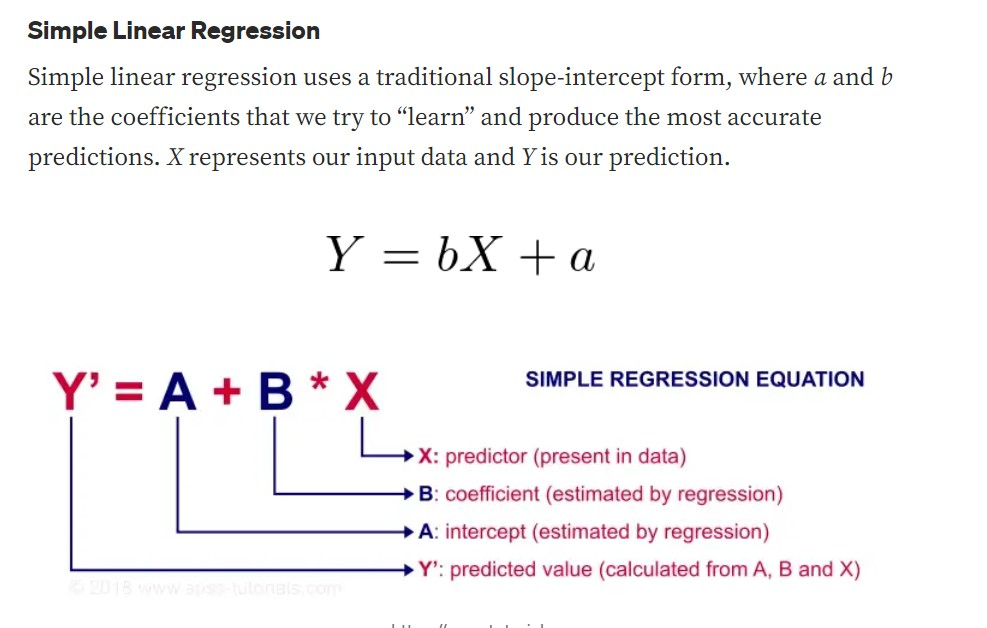

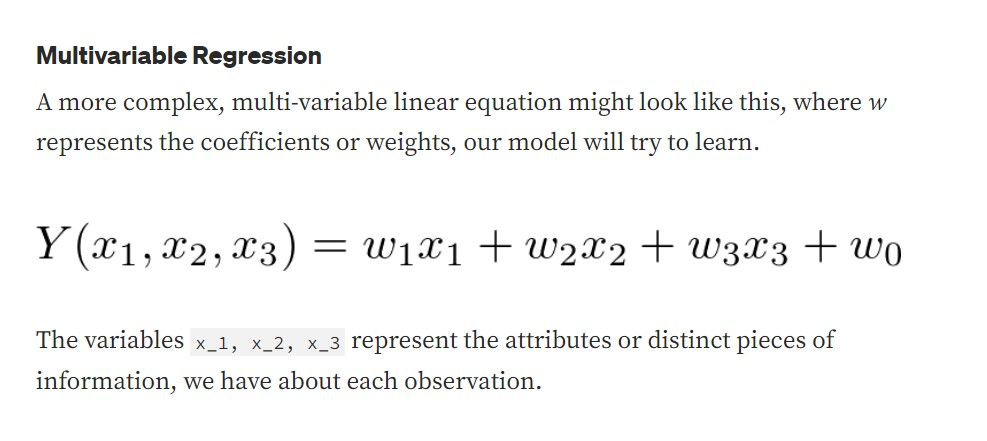

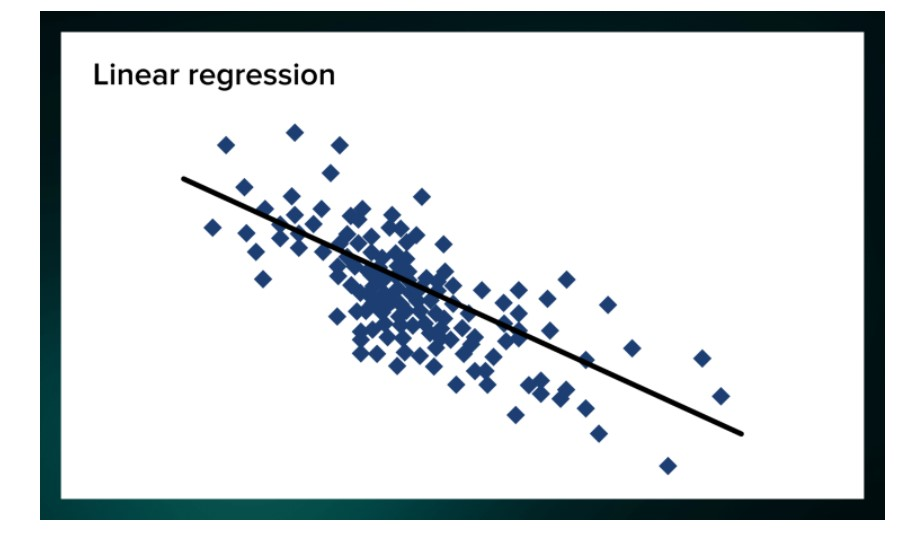

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=100,)

In [ ]:
from sklearn.linear_model import LinearRegression


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([35.31261244, 46.32061464, 18.4236424 , 48.5565414 , 41.02216957,
       41.87945836, 33.14890649, 34.04506627, 32.42167326, 42.72202745,
       40.83353645, 43.98674993, 33.85632805, 36.57449794, 39.73421484,
       19.88674511, 41.30915018, 45.6005321 , 43.7440041 , 37.35301934,
       44.42327712, 31.82934901, 48.74436789, 19.9183792 , 33.44677819,
       37.27805957, 42.7330794 , 40.75723673, 34.0307992 , 37.94700724,
       29.77344985, 42.95014001, 42.57108366, 15.25628797, 50.18605629,
       32.67218615, 43.99892006, 38.07171108, 45.8707941 , 43.57611946,
       42.80159923, 33.3099898 , 35.11270649, 51.44985184, 30.66192154,
       31.56093275, 35.83601523, 28.16930806, 43.32908504, 28.62683652,
       31.81694408, 29.29795823, 32.56522182, 46.40043031, 38.77444957,
       42.40611459, 47.16586121, 28.45911581, 43.70116438, 50.50508574,
       33.30759059, 17.39402842, 45.2373054 , 41.82301616, 31.35665347,
       46.11980556, 41.77614092, 40.16386808, 48.04283749, 51.84

In [ ]:
y_test

238    40.6
316    42.0
384    12.9
326    62.1
164    55.2
       ... 
388    27.3
85     50.8
398    23.0
81     36.8
163    55.5
Name: House price of unit area, Length: 122, dtype: float64

#Comparing Robustness of MAE, MSE and RME

In [ ]:
from sklearn import metrics

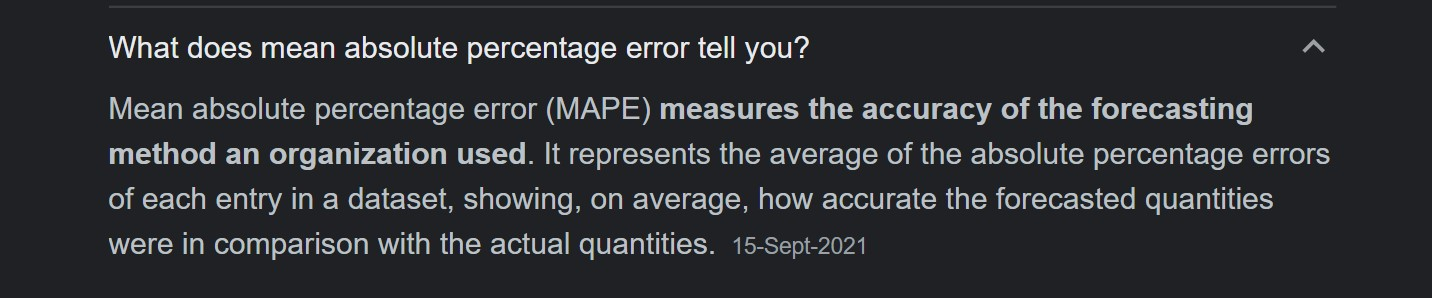

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

0.18126553933401301


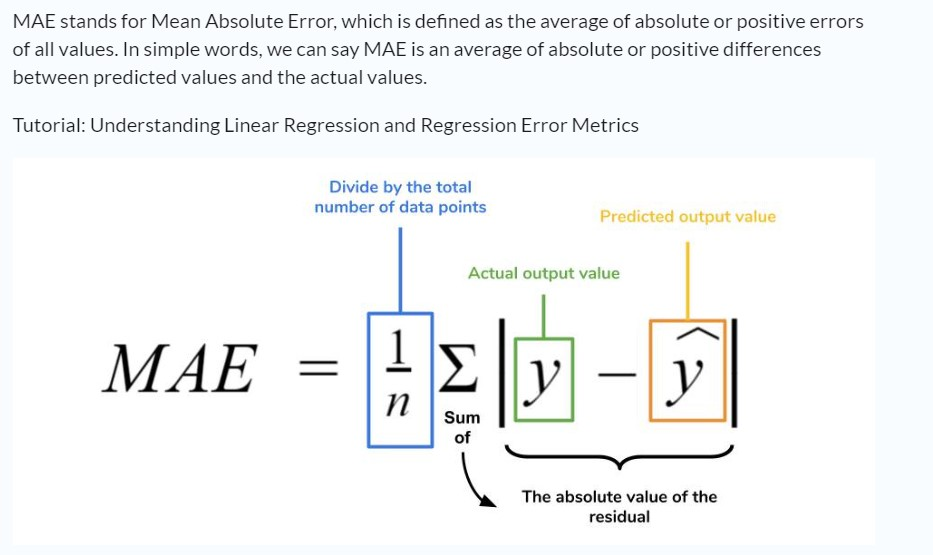

In [ ]:
MAE= metrics.mean_absolute_error(y_test,y_pred)
MAE

6.122255602055305

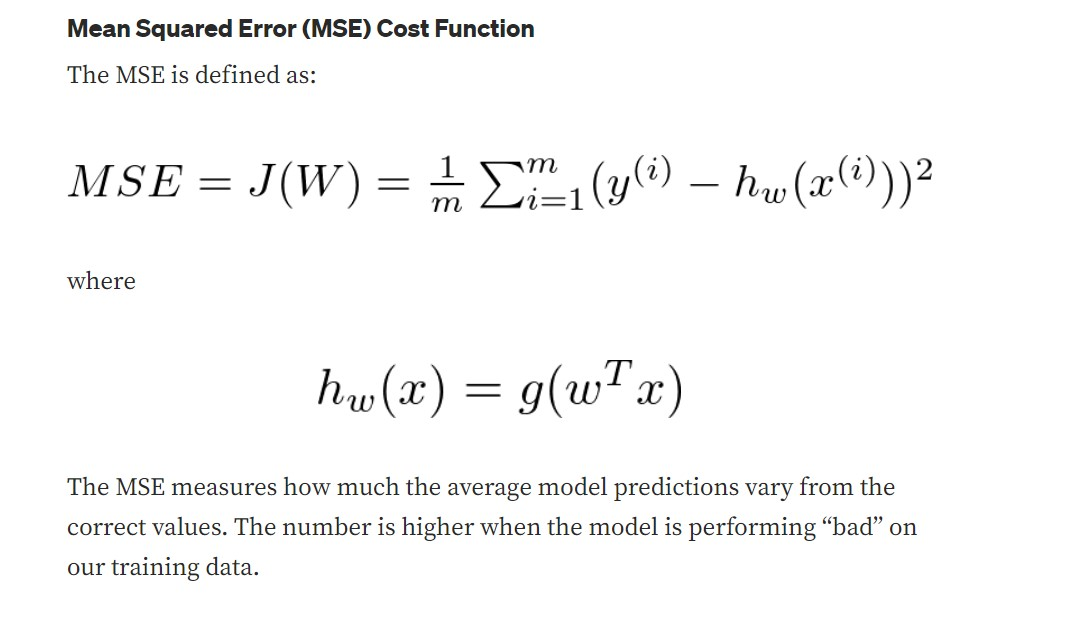

In [ ]:
MSE=metrics.mean_squared_error(y_test, y_pred)
MSE

62.52127042116699

In [ ]:
# Root Mean Squared Error (RMSE)

RME=np.sqrt(MSE)
RME

7.9070392955370465

# Polynomial regression

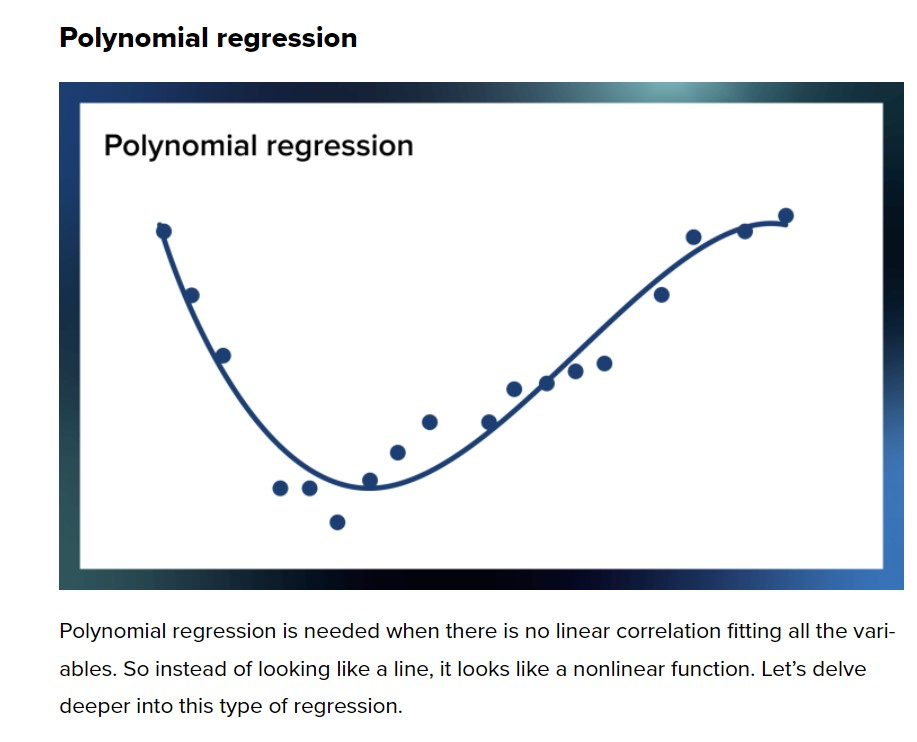

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_regs= PolynomialFeatures(degree= 1)
x_poly= poly_regs.fit_transform(x)
lin_reg_2 =LinearRegression()
lin_reg_2.fit(x_poly, y)

LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=100,)

In [ ]:
y_pred = lin_reg_2.predict(poly_regs.fit_transform(x_test))

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

0.180883158836327


In [ ]:
from sklearn import metrics

MAE= metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RME=np.sqrt(MSE)

In [ ]:
MAE

6.04727020065079

In [ ]:
MSE

60.87955806441668

In [ ]:
RME

7.802535361305111

In [ ]:
y_pred

array([35.50083178, 46.47322186, 17.33753816, 49.53478115, 41.49990105,
       42.42162971, 33.00552826, 34.6176949 , 32.96229527, 43.46259529,
       40.70044856, 43.94315473, 33.8154113 , 36.79277734, 39.7185527 ,
       19.80941682, 41.19705824, 45.38071733, 43.47568471, 37.55554696,
       45.12536935, 31.66116147, 49.67823229, 19.08559137, 33.65089025,
       37.13376419, 42.53479605, 40.73682606, 34.03142892, 38.56702788,
       29.99295028, 43.75569546, 43.43918892, 14.12385876, 50.60311645,
       33.35040027, 44.16863412, 38.09448615, 45.97088252, 43.56206392,
       43.11164617, 33.25030971, 35.18421952, 51.62922129, 30.07020392,
       31.70861662, 36.05065882, 28.28816668, 44.20773294, 28.59259922,
       31.8536519 , 29.44567883, 32.54840441, 46.50247521, 39.35858994,
       42.61540899, 47.19760964, 28.48244457, 44.19507345, 51.34043308,
       33.08835126, 17.07906113, 45.63531342, 42.26272598, 31.05818703,
       46.94069437, 42.53631819, 40.14202646, 48.57440064, 52.03

In [ ]:
y_test

238    40.6
316    42.0
384    12.9
326    62.1
164    55.2
       ... 
388    27.3
85     50.8
398    23.0
81     36.8
163    55.5
Name: House price of unit area, Length: 122, dtype: float64

#SVM
#Support Vector Machine
The goal of the SVM algorithm is to create the best line or decision boundary that can segregate n-dimensional space into classes so that we can easily put the new data point in the correct category in the future. This best decision boundary is called a hyperplane.

SVM chooses the extreme points/vectors that help in creating the hyperplane. These extreme cases are called as support vectors, and hence algorithm is termed as Support Vector Machine. Consider the below diagram in which there are two different categories that are classified using a decision boundary or hyperplane:

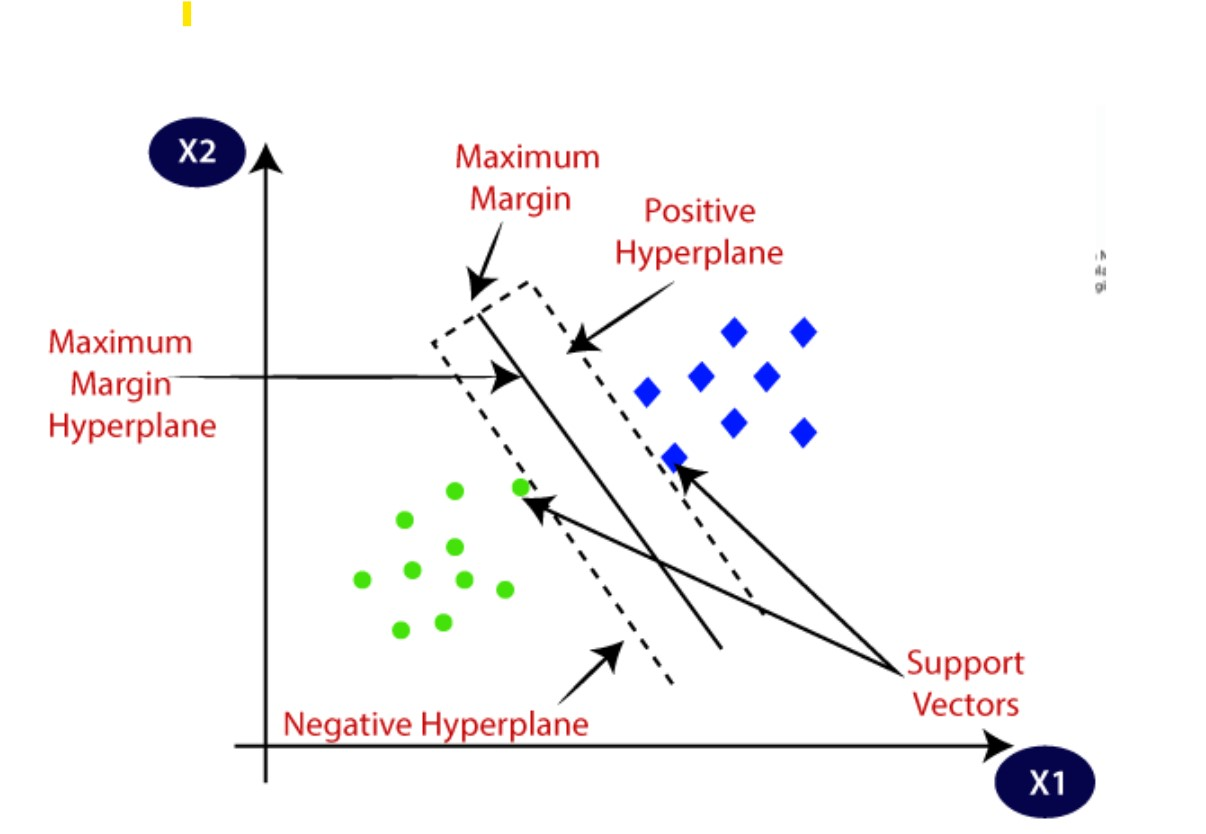

In [ ]:
x=Data[['House Age', 'Distance from nearest Metro station (km)','Number of convenience stores', 'Number of bedrooms', 'House size (sqft)']]
y=Data['House price of unit area']

In [ ]:
y=y.astype('int')

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.4, random_state=100,)


In [ ]:
from sklearn.svm import SVC


In [ ]:
model = SVC()

In [ ]:
model.fit(x_train,y_train ,sample_weight=None)


SVC()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([42, 42, 18, 42, 42, 42, 25, 42, 25, 42, 42, 42, 42, 42, 42, 18, 42,
       42, 42, 42, 42, 25, 42, 18, 42, 25, 42, 42, 25, 42, 25, 42, 42, 18,
       42, 25, 42, 42, 42, 42, 42, 42, 42, 42, 25, 25, 42, 25, 42, 25, 25,
       42, 25, 42, 42, 42, 42, 25, 42, 42, 25, 18, 42, 42, 25, 42, 42, 42,
       42, 42, 42, 42, 42, 42, 42, 18, 25, 42, 25, 25, 25, 42, 42, 42, 42,
       42, 42, 25, 42, 42, 42, 42, 42, 42, 42, 12, 25, 42, 25, 42, 42, 42,
       42, 25, 42, 18, 18, 42, 42, 42, 42, 42, 25, 42, 42, 25, 42, 25, 42,
       25, 42, 42, 25, 42, 42, 25, 42, 25, 18, 42, 42, 25, 18, 42, 42, 18,
       42, 42, 42, 25, 42, 18, 25, 25, 42, 42, 42, 42, 42, 42, 25, 42, 42,
       42, 42, 42, 42, 42, 25, 25, 25, 42])

In [ ]:
y_test

238    40
316    42
384    12
326    62
164    55
       ..
106    47
131    30
234    23
302    23
145    45
Name: House price of unit area, Length: 162, dtype: int64

In [ ]:
from sklearn import metrics

MAE= metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RME=np.sqrt(MSE)

In [ ]:
MAE

6.5

In [ ]:
MSE

70.25308641975309

In [ ]:
RME

8.38171142546396

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

0.18300045294934703


#Conclusion :



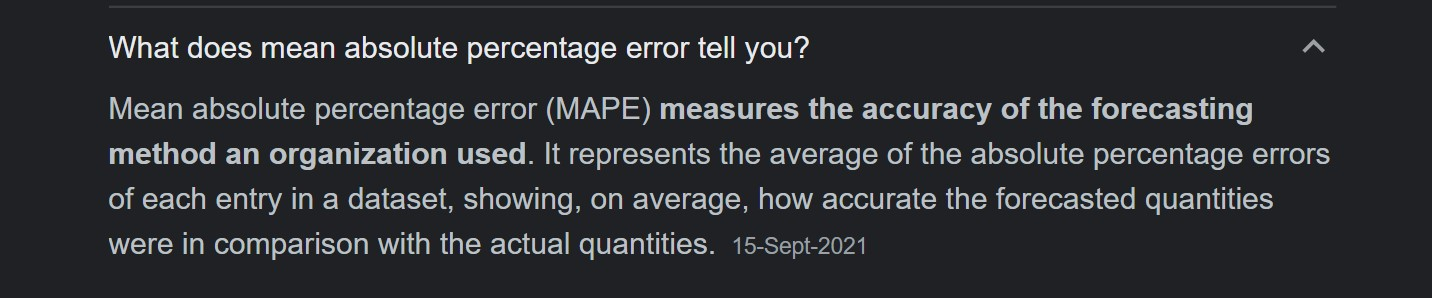

* The lower the ***Mean Absolute Percentage Error***  = The higher is the ***Accuracy*** of the Model.
* Thus the Good is the Model

* So

The **Mean Absolute Percentage Error of Multilinear Regression** Model is : 0.18126553933401301

The **Mean Absolute Percentage Error of Polynomial Regression** Model is : 0.180883158836327

The **Mean Absolute Percentage Error of Support Vector Machine** [ SVM ] Model is : 0.18300045294934703

* So according to above results for this given data set **Polynomial Regression Model** is Best.